# Loading LVM DAP Data as Needed
We can now load small sections of the table at a time, and actively load more columns as they are needed
This will be done automatically if a function asks

In [1]:
# Initial Imports
import numpy as np
import matplotlib.pyplot as plt
%matplotlib ipympl
from dk_lvm_tools import dap
import astropy.units as u

## Initial Load
This will start the table with just minimal information to allow for pruning down with sky_section, etc...

You can also add in an option "WHERE" query statement if you want to load less than the full table from the start

In [2]:
filename = "/mnt/r1/Astronomy.DK Dropbox/SDSS_LVM/Data/DAP_Table_v1.2.1_lite_flux_vel_LSR.parquet"

# Optional where statement
parquet_where = """
    WHERE "GAL-LAT" < 5. AND "GAL-LAT" > -5
"""

# load initial table
lvm = dap(parquet_pattern=filename,
          parquet_where=parquet_where, # comment out this line to load the entire table
         )

In [3]:
# Only basic table info by default
lvm

id,ra,dec,GAL-LON,GAL-LAT
,deg,deg,deg,deg
object,float64,float64,float64,float64
13292.10,148.6508674779044,-53.631816659940974,278.50774648826456,0.6369602957022592
13292.100,148.60808556332532,-53.59201714726013,278.4631378301501,0.6524033193659068
13292.1000,148.68797940006434,-53.445716177588544,278.40957797057854,0.796598194312276
13292.1001,148.6815834930906,-53.43614011501586,278.4006491999981,0.8017467457329185
13292.1002,148.67519046868156,-53.42656371190785,278.3917204078293,0.8068952771854634
13292.1003,148.66880032504798,-53.41698696915738,278.3827915945058,0.8120437882116827
13292.1004,148.65173310458235,-53.415507590575245,278.3738959351661,0.8068919439180984
13292.1005,148.65807809530932,-53.42506587709568,278.3827935292189,0.8017434472397548


In [4]:
lvm.parquet_pattern

'/mnt/r1/Astronomy.DK Dropbox/SDSS_LVM/Data/DAP_Table_v1.2.1_lite_flux_vel_LSR.parquet'

# Get specific columns
Check the lvm dap data model on the wiki for column names you may want and just ask for them and it will load

In [5]:
ha_flux = lvm["flux_Halpha_6562.85"]

lvm

id,ra,dec,GAL-LON,GAL-LAT,flux_Halpha_6562.85
,deg,deg,deg,deg,lvm_flux
object,float64,float64,float64,float64,float64
13292.10,148.6508674779044,-53.631816659940974,278.50774648826456,0.6369602957022592,482.75799722343874
13292.100,148.60808556332532,-53.59201714726013,278.4631378301501,0.6524033193659068,357.2275396205338
13292.1000,148.68797940006434,-53.445716177588544,278.40957797057854,0.796598194312276,327.81003484976003
13292.1001,148.6815834930906,-53.43614011501586,278.4006491999981,0.8017467457329185,277.48005638482675
13292.1002,148.67519046868156,-53.42656371190785,278.3917204078293,0.8068952771854634,348.9917318571665
13292.1003,148.66880032504798,-53.41698696915738,278.3827915945058,0.8120437882116827,375.07630196506125
13292.1004,148.65173310458235,-53.415507590575245,278.3738959351661,0.8068919439180984,380.352421341379
13292.1005,148.65807809530932,-53.42506587709568,278.3827935292189,0.8017434472397548,401.923892147226


It can be a little slow if the table is still the full size - cut it down to smaller sections if you are focusing on a small area first

In [6]:
lvm_cut = lvm.sky_section(bounds = [-10,10,-5,5]*u.deg)

In [7]:
lvm_cut

id,ra,dec,GAL-LON,GAL-LAT,flux_Halpha_6562.85
,deg,deg,deg,deg,lvm_flux
object,float64,float64,float64,float64,float64
39621.10,261.9602002503402,-34.26543944558846,353.47280000759883,0.32359573244591255,2932.293951249252
39621.100,261.9075623669316,-34.24712726932002,353.463841040882,0.3699412530991692,4941.051762586717
39621.1000,261.8544000260845,-34.09973044396575,353.5618677733742,0.48848096258843315,3657.495791251725
39621.1001,261.84405189237714,-34.09400472193573,353.5618562470632,0.4987870231187272,3599.3133196034405
39621.1002,261.8337051596702,-34.0882781329978,353.5618447207172,0.5090930826478369,3255.334099604222
39621.1003,261.8233598283539,-34.08255067782699,353.56183319433615,0.5193991405088838,3033.1937026205533
39621.1004,261.8122317405866,-34.087102249132386,353.55292068274554,0.5245208775438349,3934.4938320386186
39621.1005,261.8225392627022,-34.0928285766102,353.5529165938596,0.5142418415418559,3614.7262479443607


## Functions that need other columns will automatically load them

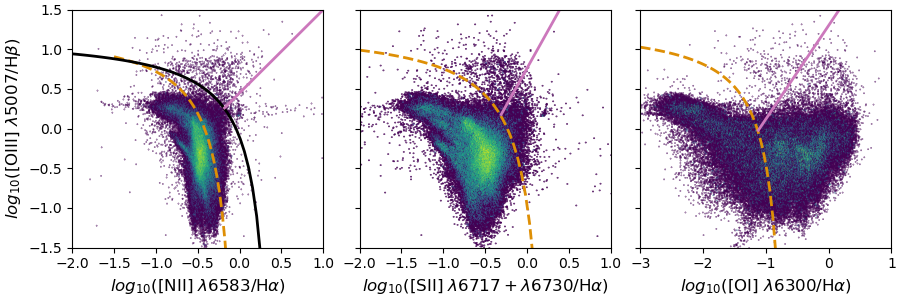

In [8]:
fig = lvm_cut.plot_multi_bpt()

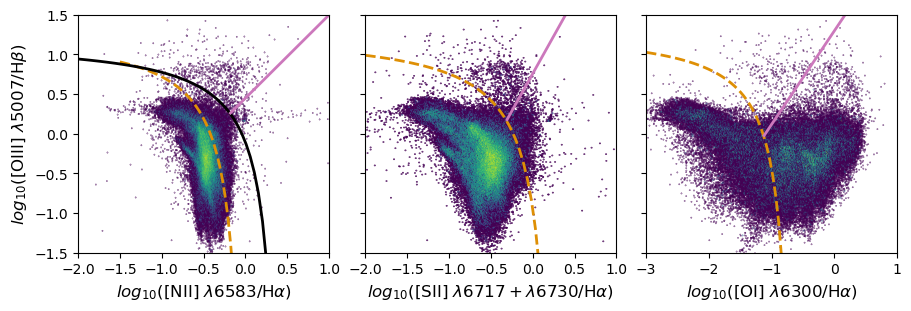

In [9]:
fig

In [10]:
# More columns are present now
lvm_cut.colnames

['id',
 'ra',
 'dec',
 'GAL-LON',
 'GAL-LAT',
 'flux_Halpha_6562.85',
 'flux_[OIII]_5006.84',
 'e_flux_[OIII]_5006.84',
 'flux_Hbeta_4861.36',
 'e_flux_Hbeta_4861.36',
 'e_flux_Halpha_6562.85',
 'flux_[NII]_6583.45',
 'e_flux_[NII]_6583.45',
 'flux_[SII]_6716.44',
 'e_flux_[SII]_6716.44',
 'flux_[SII]_6730.82',
 'e_flux_[SII]_6730.82',
 'flux_[OI]_6300.3',
 'e_flux_[OI]_6300.3']

## Bulk load columns of interest:

In [12]:
colnames_list = [
    "flux_[SIII]_9531.1", 
    "e_flux_[SIII]_9531.1",
    "vel_[SII]_6716.44",
    "e_vel_[SII]_6716.44",
    "vel_[SIII]_9531.1",
    "e_vel_[SIII]_9531.1",
    "vel_Halpha_6562.85",
    "e_vel_Halpha_6562.85",
]

lvm_cut.load_column_list(colnames_list)

In [13]:
lvm_cut.colnames

['id',
 'ra',
 'dec',
 'GAL-LON',
 'GAL-LAT',
 'flux_Halpha_6562.85',
 'flux_[OIII]_5006.84',
 'e_flux_[OIII]_5006.84',
 'flux_Hbeta_4861.36',
 'e_flux_Hbeta_4861.36',
 'e_flux_Halpha_6562.85',
 'flux_[NII]_6583.45',
 'e_flux_[NII]_6583.45',
 'flux_[SII]_6716.44',
 'e_flux_[SII]_6716.44',
 'flux_[SII]_6730.82',
 'e_flux_[SII]_6730.82',
 'flux_[OI]_6300.3',
 'e_flux_[OI]_6300.3',
 'flux_[SIII]_9531.1',
 'e_flux_[SIII]_9531.1',
 'vel_[SII]_6716.44',
 'e_vel_[SII]_6716.44',
 'vel_[SIII]_9531.1',
 'e_vel_[SIII]_9531.1',
 'vel_Halpha_6562.85',
 'e_vel_Halpha_6562.85']

/home/dk/repos/dk_lvm_tools/dk_lvm_tools/dapTableMixin.py:2356: UserWarning: Only one of 'bins' and 'norm' arguments can be supplied, ignoring bins='log'
  hb = ax.hexbin(lon[valid_mask], velocity[valid_mask],


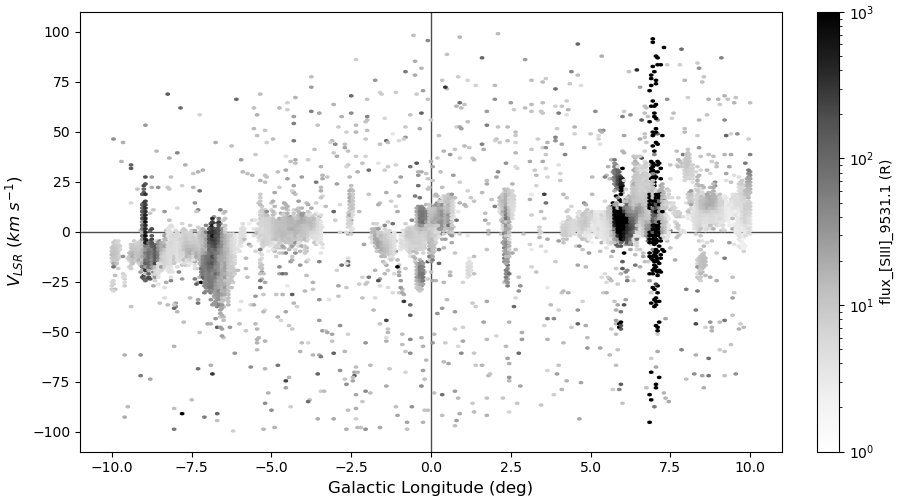

In [16]:
fig = plt.figure(figsize = (9,5), constrained_layout = True)
fig = lvm_cut.plot_lv( "flux_[SIII]_9531.1", snr_cut = 10, 
                  gridsize = 200,
                  fig = fig, 
                  velocity_bounds = [-100,100]*u.km/u.s, 
                  cmap = "Greys")
ax = fig.axes[0]

# ax.set_xlim(33,-162)
ax.set_ylim(-110,110)

ax.axhline(0, zorder = -1, color = "k", alpha = 0.7, lw = 1, ls = "-")
ax.axvline(0, zorder = -1, color = "k", alpha = 0.7, lw = 1, ls = "-")

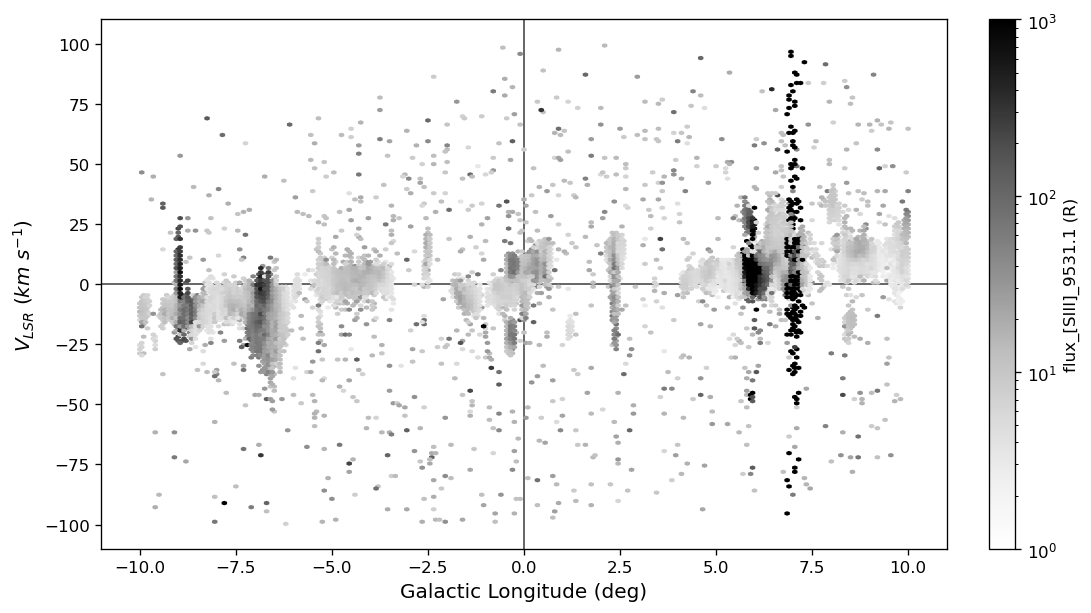

In [17]:
fig